In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import classification_report

### -> Dataset import

In [3]:
df = pd.read_csv("credit_risk_dataset.csv")
df.shape

(32581, 12)

### -> First 5 row 

In [4]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


### -> Check null value and fill null value

In [5]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [6]:
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

### -> columns

In [7]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='str')

### -> Check dataset is imbalance or not

In [8]:
df["loan_status"].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

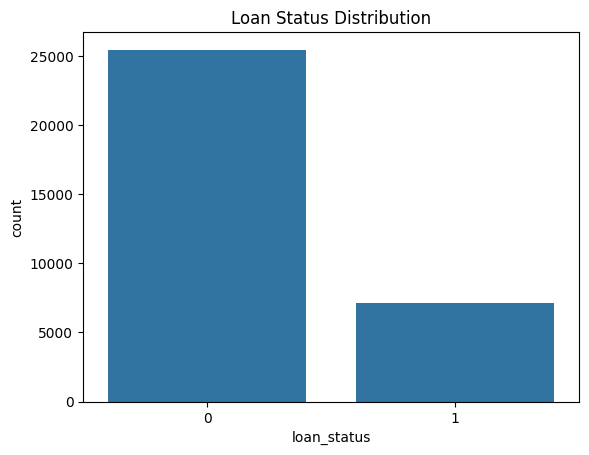

In [9]:
sns.countplot(x='loan_status', data=df)
plt.title("Loan Status Distribution")
plt.show()

In [10]:
print(df['person_home_ownership'].value_counts().reset_index(),"\n")
print(df['loan_intent'].value_counts().reset_index(),"\n")
print(df['loan_grade'].value_counts().reset_index(),"\n")
print(df['cb_person_default_on_file'].value_counts().reset_index())

  person_home_ownership  count
0                  RENT  16446
1              MORTGAGE  13444
2                   OWN   2584
3                 OTHER    107 

         loan_intent  count
0          EDUCATION   6453
1            MEDICAL   6071
2            VENTURE   5719
3           PERSONAL   5521
4  DEBTCONSOLIDATION   5212
5    HOMEIMPROVEMENT   3605 

  loan_grade  count
0          A  10777
1          B  10451
2          C   6458
3          D   3626
4          E    964
5          F    241
6          G     64 

  cb_person_default_on_file  count
0                         N  26836
1                         Y   5745


### -> Use Label Encoding

In [11]:
# person_home_ownership
home_map = {
    'RENT': 0,
    'MORTGAGE': 1,
    'OWN': 2,
    'OTHER': 3
}
df['person_home_ownership'] = df['person_home_ownership'].map(home_map)

# loan_intent
intent_map = {
    'EDUCATION': 0,
    'MEDICAL': 1,
    'VENTURE': 2,
    'PERSONAL': 3,
    'DEBTCONSOLIDATION': 4,
    'HOMEIMPROVEMENT': 5
}
df['loan_intent'] = df['loan_intent'].map(intent_map)

# loan_grade
grade_map = {
    'A': 7,
    'B': 6,
    'C': 5,
    'D': 4,
    'E': 3,
    'F': 2,
    'G': 1
}
df['loan_grade'] = df['loan_grade'].map(grade_map)

# cb_person_cred_hist_length
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({
    'N': 0,
    'Y': 1
})

In [12]:
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,0,123.0,3,4,35000,16.02,1,0.59,1,3
1,21,9600,2,5.0,0,6,1000,11.14,0,0.10,0,2
2,25,9600,1,1.0,1,5,5500,12.87,1,0.57,0,3
3,23,65500,0,4.0,1,5,35000,15.23,1,0.53,0,2
4,24,54400,0,8.0,1,5,35000,14.27,1,0.55,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,1,1.0,3,5,5800,13.16,0,0.11,0,30
32577,54,120000,1,4.0,3,7,17625,7.49,0,0.15,0,19
32578,65,76000,0,3.0,5,6,35000,10.99,1,0.46,0,28
32579,56,150000,1,5.0,3,6,15000,11.48,0,0.10,0,26


### -> Check Correlation

                            loan_status
loan_status                    1.000000
loan_percent_income            0.379366
loan_int_rate                  0.319360
cb_person_default_on_file      0.179141
loan_amnt                      0.105376
loan_intent                    0.061209
cb_person_cred_hist_length    -0.015529
person_age                    -0.021629
person_emp_length             -0.082182
person_income                 -0.144449
person_home_ownership         -0.223778
loan_grade                    -0.373080


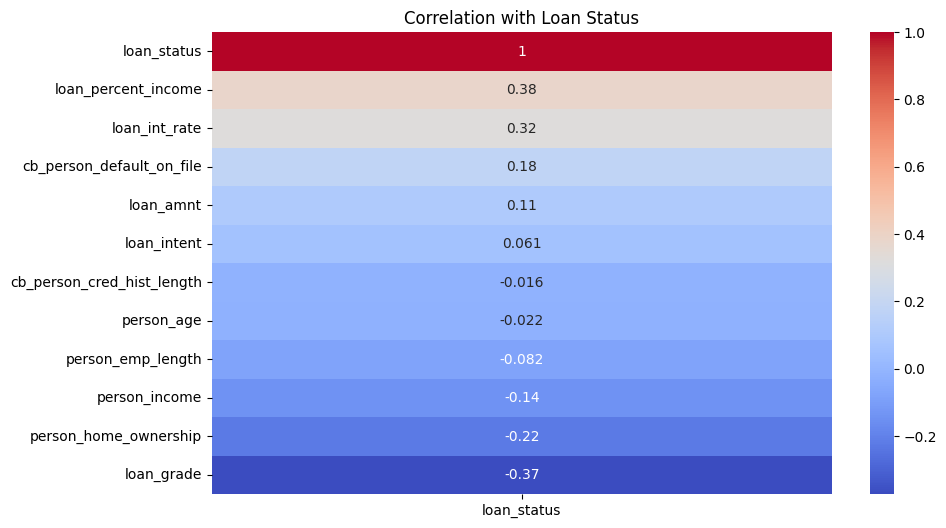

In [13]:
corr = df.corr()[['loan_status']].sort_values(by='loan_status',ascending=False)
print(corr)
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation with Loan Status")
plt.show()

In [14]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,0,123.0,3,4,35000,16.02,1,0.59,1,3
1,21,9600,2,5.0,0,6,1000,11.14,0,0.10,0,2
2,25,9600,1,1.0,1,5,5500,12.87,1,0.57,0,3
3,23,65500,0,4.0,1,5,35000,15.23,1,0.53,0,2
4,24,54400,0,8.0,1,5,35000,14.27,1,0.55,1,4


In [15]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='str')

## Features used:

#### - person_income
#### - person_home_ownership
#### - person_emp_length
#### - loan_intent
#### - loan_grade
#### - loan_amnt
#### - loan_int_rate
#### - loan_percent_income
#### - cb_person_default_on_file

In [16]:
X = df.drop(['loan_status','cb_person_cred_hist_length','person_age'],axis=1)
y = df['loan_status']

### -> Decision Tree

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [19]:
y_pred_dt = dt.predict(X_test)

In [20]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

Accuracy: 0.8875249347859444
Precision: 0.7296774193548388
Recall: 0.7826989619377163
F1 Score: 0.7552587646076795


### -> Random Forest 

In [21]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [22]:
y_pred_rf = rf.predict(X_test)

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.9311032683750192
Precision: 0.9543795620437956
Recall: 0.7238754325259515
F1 Score: 0.8232979142070052


### -> Decision Tree vs Random Forest

In [24]:
results = pd.DataFrame({
    'Model': ['Decision Tree','Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_dt), precision_score(y_test, y_pred_rf)],
    'Recall': [recall_score(y_test, y_pred_dt), recall_score(y_test, y_pred_rf)],
    'F1 Score': [f1_score(y_test, y_pred_dt), f1_score(y_test, y_pred_rf)]
})

print(results)

           Model  Accuracy  Precision    Recall  F1 Score
0  Decision Tree  0.887525   0.729677  0.782699  0.755259
1  Random Forest  0.931103   0.954380  0.723875  0.823298


### -> Two algorithms were used: Decision Tree and Random Forest.
### -> Random Forest performed better across evaluation metrics
### -> (Accuracy, Precision, Recall, and F1 Score).
### -> Hence, Random Forest is selected as the final model.
### -> The next step is to evaluate it for potential overfitting.

### -> Check Overfitting

In [25]:
train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

Train Accuracy: 1.0
Test Accuracy: 0.9311032683750192


In [26]:
print("Train F1:", f1_score(y_train, train_pred))
print("Test F1:", f1_score(y_test, test_pred))

Train F1: 1.0
Test F1: 0.8232979142070052


### Plot ROC curve and compute AUC to evaluate how well the model distinguishes between default and non-default cases

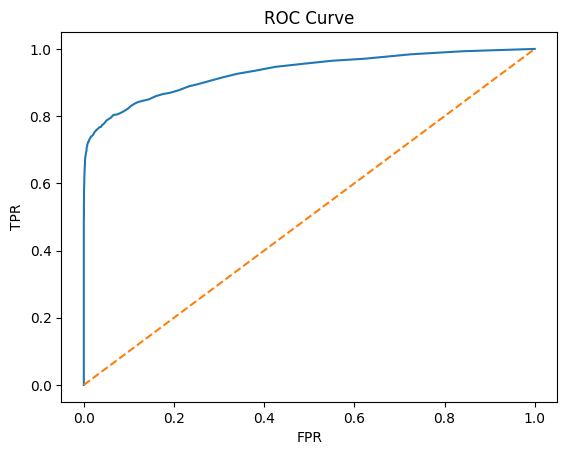

AUC: 0.9313935385807692


In [27]:
y_prob = rf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()
print("AUC:", roc_auc_score(y_test, y_prob))

### Model report

In [28]:
print(classification_report(y_test, rf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5072
           1       0.95      0.72      0.82      1445

    accuracy                           0.93      6517
   macro avg       0.94      0.86      0.89      6517
weighted avg       0.93      0.93      0.93      6517



## Conclusion:
### In this project, multiple classification models were applied to predict creditworthiness. Among them, the Random Forest model performed the best with an accuracy of 93% and F1-score of 0.82. The model also achieved an AUC score of 0.93, indicating excellent performance in distinguishing between risky and safe customers. Therefore, Random Forest was selected as the final model.